In [1]:
import numpy as np
import networkx as nx
import trimesh


import pyvista as pv
import matplotlib.pyplot as plt

from src import vis

from src.stratified import Stratified

from src.timing import Timer

# Load an Example

In [2]:
loaded_mesh = trimesh.load("data/nm-mesh-iso.ply")
#loaded_mesh = trimesh.load("data/drop-iso.ply")
#loaded_mesh = trimesh.load("data/drop.ply")
#loaded_mesh = trimesh.load("data/goats-004-2.obj")

vertices = loaded_mesh.vertices
faces = loaded_mesh.faces

print(vertices.shape, faces.shape)

(11364, 3) (22984, 3)


In [ ]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.9)
pl.show()

Widget(value='<iframe src="http://localhost:34223/index.html?ui=P_0x70074c029cd0_0&reconnect=auto" class="pyvi…

 JS Error => TypeError: Cannot create proxy with a non-object as target or handler


# Detect Strats

In [4]:
strats = Stratified(faces, vertices)

In [5]:
cmap = 'rainbow'
if strats.n_strats <= 20:
    cmap = 'tab20'
if strats.n_strats <= 10:
    cmap = 'tab10'

mesh = vis.get_pv_mesh(strats.vertices, strats.faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, scalars=strats.strats_labels, categories=True, cmap=cmap, smooth_shading=False, show_edges=True, opacity=1.0)

vis.add_graph_to_plotter(pl, strats.skeleton_graph, pos={node: strats.vertices[node] for node in strats.skeleton_graph.nodes()}, 
                         node_color='white', edge_color='white')
pl.show()

Widget(value='<iframe src="http://localhost:34223/index.html?ui=P_0x700693423860_1&reconnect=auto" class="pyvi…

In [6]:
strats.define_values_on_skeleton()

status: optimal
objective: 0.28021460429800654
n: [1 3 3 3 2 3]
s: 0.48036293083821785


array([nan, nan, nan, ..., nan, nan, nan], shape=(11364,))

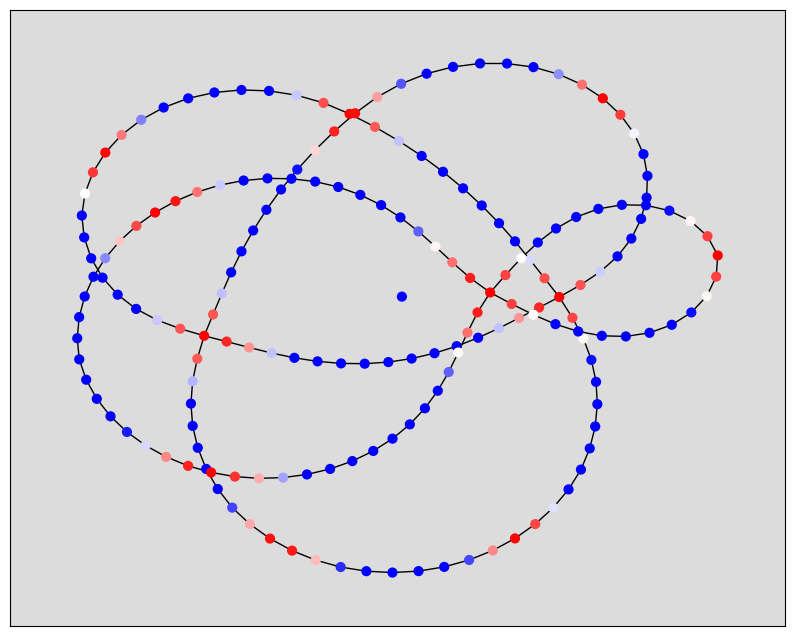

In [7]:
node_colors = plt.get_cmap('bwr')(strats.values[list(strats.skeleton_graph.nodes())])

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

nx.draw_networkx(strats.skeleton_graph, node_color=node_colors, ax=ax,
                 pos=nx.kamada_kawai_layout(strats.skeleton_graph), node_size=40, with_labels=False)
ax.set_facecolor('gainsboro')

plt.show()

In [8]:
pl = pv.Plotter(window_size=(600, 600))

mesh = vis.get_pv_mesh(strats.vertices, strats.faces)
pl.add_mesh(mesh, scalars=np.nan_to_num(strats.values, nan=0), categories=False, cmap='bwr', smooth_shading=False, show_edges=True, opacity=1.0)

pl.show()

Widget(value='<iframe src="http://localhost:34223/index.html?ui=P_0x70069090f7d0_2&reconnect=auto" class="pyvi…

In [9]:
import pandas as pd

pd.Series(strats.values).value_counts(dropna=False)

 NaN         11182
 1.000000        4
-0.999988        2
-0.568074        1
-0.171758        1
             ...  
-0.980399        1
-0.816700        1
-0.182195        1
 0.516808        1
 0.943452        1
Name: count, Length: 179, dtype: int64

In [10]:
V, F, old2new, new2old = strats.get_stratum(1)

print(f'V.shape = {V.shape}')
print(f'F.shape = {F.shape}')
print(f'old2new.shape = {old2new.shape}')
print(f'new2old.shape = {new2old.shape}')

V.shape = (194, 3)
F.shape = (338, 3)
old2new.shape = (11364,)
new2old.shape = (194,)


In [11]:
from src import triangletools

SV, SF, SVI = triangletools.cut_mesh_along_edges(strats.vertices, strats.faces, strats.skeleton_edges)


print(f'strats.vertices.shape = {strats.vertices.shape}')
print(f'strats.faces.shape = {strats.faces.shape}')
print(f'strats.skeleton_edges.shape = {strats.skeleton_edges.shape}')
print(f'SV.shape = {SV.shape}')
print(f'SF.shape = {SF.shape}')
print(f'SVI.shape = {SVI.shape}')

strats.vertices.shape = (11364, 3)
strats.faces.shape = (22984, 3)
strats.skeleton_edges.shape = (184, 2)
SV.shape = (11808, 3)
SF.shape = (22984, 3)
SVI.shape = (11808,)


In [12]:
print('Before remsah')
print(f'strats.vertices.shape = {strats.vertices.shape}')
print(f'strats.faces.shape = {strats.faces.shape}')
print(f'strats.edges.shape = {strats.edges.shape}')
print(f'strats.skeleton_edges.shape = {strats.skeleton_edges.shape}')
print()

with Timer():
    strats.remash()

print()
print('After remash')
print(f'strats.vertices.shape = {strats.vertices.shape}')
print(f'strats.faces.shape = {strats.faces.shape}')
print(f'strats.edges.shape = {strats.edges.shape}')
print(f'strats.skeleton_edges.shape = {strats.skeleton_edges.shape}')

Before remsah
strats.vertices.shape = (11364, 3)
strats.faces.shape = (22984, 3)
strats.edges.shape = (34348, 2)
strats.skeleton_edges.shape = (184, 2)

Process done in 10.6317 seconds.

After remash
strats.vertices.shape = (11368, 3)
strats.faces.shape = (22992, 3)
strats.edges.shape = (34370, 2)
strats.skeleton_edges.shape = (184, 2)


In [13]:
strats.define_values_on_skeleton()

status: optimal
objective: 0.28021460429800654
n: [1 3 3 3 2 3]
s: 0.48036293083821785


array([nan, nan, nan, ..., nan, nan, nan], shape=(11368,))

In [14]:
edges = '''[[  0  27]
 [  0 146]
 [  1  28]
 [  1 145]
 [  2  29]
 [  2 170]
 [  3  30]
 [  3 169]
 [  4 145]
 [  4 147]
 [  5 146]
 [  5 148]
 [  6 169]
 [  6 171]
 [  7 170]
 [  7 172]
 [  8 147]
 [  8 152]
 [  9 148]
 [  9 151]
 [ 10 159]
 [ 10 171]
 [ 11 160]
 [ 11 172]
 [ 12 149]
 [ 12 151]
 [ 13 150]
 [ 13 152]
 [ 14 157]
 [ 14 160]
 [ 15 158]
 [ 15 159]
 [ 19 154]
 [ 19 156]
 [ 20 153]
 [ 20 155]
 [ 21 156]
 [ 21 163]
 [ 22 155]
 [ 22 164]
 [ 23 161]
 [ 23 163]
 [ 24 162]
 [ 24 164]
 [ 25  32]
 [ 25 161]
 [ 26  31]
 [ 26 162]
 [ 27  34]
 [ 28  33]
 [ 29  35]
 [ 30  36]
 [ 31  37]
 [ 32  38]
 [ 33  40]
 [ 34  39]
 [ 35  41]
 [ 36  42]
 [ 37  44]
 [ 38  43]
 [ 39  46]
 [ 40  45]
 [ 41  47]
 [ 42  48]
 [ 43  49]
 [ 44  50]
 [ 45  51]
 [ 46  52]
 [ 47  53]
 [ 48  54]
 [ 49  56]
 [ 50  55]
 [ 51  58]
 [ 52  57]
 [ 53  59]
 [ 54  60]
 [ 55  62]
 [ 56  61]
 [ 57  63]
 [ 58  64]
 [ 59  65]
 [ 60  66]
 [ 61  68]
 [ 62  67]
 [ 63  69]
 [ 64  70]
 [ 65  71]
 [ 66  72]
 [ 67  74]
 [ 68  73]
 [ 69  76]
 [ 70  75]
 [ 71  77]
 [ 72  78]
 [ 73  79]
 [ 74  80]
 [ 75  81]
 [ 76  82]
 [ 77  83]
 [ 78  84]
 [ 79  86]
 [ 80  85]
 [ 81  87]
 [ 82  88]
 [ 83  89]
 [ 84  90]
 [ 85  91]
 [ 86  92]
 [ 87  93]
 [ 88  94]
 [ 89  96]
 [ 90  95]
 [ 91  97]
 [ 92  98]
 [ 93 100]
 [ 94  99]
 [ 95 102]
 [ 96 101]
 [ 97 103]
 [ 98 104]
 [ 99 105]
 [100 106]
 [101 107]
 [102 108]
 [103 110]
 [104 109]
 [105 112]
 [106 111]
 [107 114]
 [108 113]
 [109 115]
 [110 116]
 [111 117]
 [112 118]
 [113 120]
 [114 119]
 [115 142]
 [116 143]
 [117 166]
 [118 165]
 [119 186]
 [120 185]
 [121 165]
 [121 168]
 [122 166]
 [122 167]
 [123 186]
 [123 187]
 [124 185]
 [124 188]
 [125 167]
 [125 175]
 [126 168]
 [126 176]
 [127 187]
 [127 192]
 [128 188]
 [128 191]
 [129 174]
 [129 175]
 [130 173]
 [130 176]
 [131 189]
 [131 192]
 [132 190]
 [132 191]
 [136 177]
 [136 179]
 [137 178]
 [137 180]
 [138 179]
 [138 183]
 [139 180]
 [139 184]
 [140 182]
 [140 184]
 [141 181]
 [141 183]
 [142 181]
 [143 182]
 [144 340]
 [144 341]
 [144 342]
 [144 343]
 [144 356]
 [144 357]
 [144 373]
 [144 374]
 [144 377]
 [340 341]
 [340 373]
 [341 377]
 [342 343]
 [342 374]
 [343 373]
 [356 357]
 [356 377]
 [357 374]]'''.replace(']', '').replace('[', '').replace('\n', ' ')

while edges.find('  ') != -1:
    edges = edges.replace('  ', ' ')

edges = np.array(edges.split()).astype(int)

edges = edges.reshape(-1, 2)
edges

g_edges = nx.Graph()
g_edges.add_edges_from(edges)

stratum_vertices, stratum_faces, global2stratum, stratum2global = strats.get_stratum(0)
pos_stratum = {node: stratum_vertices[node] for node in g_edges.nodes()}
pos_global = {node: strats.vertices[node] for node in g_edges.nodes()}


pl = pv.Plotter(window_size=(600, 600))

mesh = vis.get_pv_mesh(strats.vertices, strats.faces)

pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.4)

vis.add_graph_to_plotter(pl, g_edges, pos_stratum, node_color='red')
vis.add_graph_to_plotter(pl, g_edges, pos_global, node_color='blue')

pl.show()

Widget(value='<iframe src="http://localhost:34223/index.html?ui=P_0x70066492fad0_3&reconnect=auto" class="pyvi…

In [15]:
strats.define_values_on_stratum(0, eigen_index=4, eval_harmonic_ratio=None, eps=None)

IndexError: arrays used as indices must be of integer (or boolean) type

In [ ]:
pl = pv.Plotter(window_size=(600, 600))

mesh = vis.get_pv_mesh(strats.vertices, strats.faces)

pl.add_mesh(mesh, scalars=strats.values, categories=False, cmap='viridis', smooth_shading=False, show_edges=True, opacity=1.0)

pl.show()

Widget(value='<iframe src="http://localhost:38097/index.html?ui=P_0x7914d930be60_3&reconnect=auto" class="pyvi…